##Qwen + LoRA for SI

In [ ]:
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; get_numpy = f"numpy=={numpy.__version__}"; get_pil = f"pillow=={PIL.__version__}"
    except: get_numpy = "numpy"; get_pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    get_vllm, get_triton = ("vllm==0.9.2", "triton==3.2.0") if is_t4 else ("vllm==0.10.2", "triton")
    !uv pip install -qqq --upgrade \
        unsloth {get_vllm} {get_numpy} {get_pil} torchvision bitsandbytes xformers
    !uv pip install -qqq {get_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2
!pip uninstall -y protobuf
!pip install "protobuf<5"

In [ ]:
!git clone https://github.com/vrdn-23/SemEval-2020

Cloning into 'SemEval-2020'...
remote: Enumerating objects: 2268, done.
remote: Counting objects: 100% (2268/2268), done.
remote: Compressing objects: 100% (1494/1494), done.
remote: Total 2268 (delta 735), reused 2200 (delta 695), pack-reused 0 (from 0)
Receiving objects: 100% (2268/2268), 9.97 MiB | 10.38 MiB/s, done.
Resolving deltas: 100% (735/735), done.


In [ ]:
from pathlib import Path

base_path = Path("SemEval-2020/datasets")

articles_path = base_path / "train-articles"
si_labels_path = base_path / "train-labels-task1-span-identification"

articles = {}
for txt in articles_path.glob("*.txt"):
    article_id = txt.stem.replace("article", "")
    articles[article_id] = txt.read_text(encoding="utf-8")

si_labels = {}
for label in si_labels_path.glob("*.labels"):
    article_id = label.stem.replace("article", "").replace(".task1-SI", "")
    spans = []
    for line in label.read_text(encoding="utf-8").splitlines():
        _, start, end = line.split("\t")
        spans.append((int(start), int(end)))
    si_labels[article_id] = spans

In [ ]:
import re

token_pattern = re.compile(r"\w+|[^\w\s]")

def tokenize_and_label(text, spans):
    tokens, labels = [], []

    for match in re.finditer(token_pattern, text):
        token = match.group()
        start, end = match.span()

        label = "O"
        for s, e in spans:
            if start >= s and start < e:
                label = "B" if start == s else "I"
                break

        tokens.append(token)
        labels.append(label)

    return tokens, labels

In [ ]:
from datasets import Dataset

data = []
for article_id, text in articles.items():
    spans = si_labels.get(article_id, [])
    tokens, labels = tokenize_and_label(text, spans)
    data.append({"tokens": tokens, "labels": labels})

dataset = Dataset.from_list(data)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
label_list = ["B", "I", "O"]
num_labels = len(label_list)
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

def tokenize_dataset(example):
    text = " ".join(example["tokens"])
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=512,
    )
    labels = [label2id[l] for l in example["labels"]]

    if len(labels) > len(enc["input_ids"]):
        labels = labels[:len(enc["input_ids"])]
    else:
        labels += [-100] * (len(enc["input_ids"]) - len(labels))
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": labels
    }

dataset = dataset.map(tokenize_dataset, remove_columns=["tokens", "labels"])

In [ ]:
split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]

In [ ]:
from transformers.models.qwen2 import Qwen2PreTrainedModel, Qwen2Model
from typing import Optional, Union, List
import torch
import torch.nn as nn
from transformers.modeling_outputs import SequenceClassifierOutput

class Qwen2ForTokenClassification(Qwen2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.model = Qwen2Model(config)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels, bias=False)
        self.post_init()

    def forward(
        self,
        input_ids: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[List[torch.FloatTensor]] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None
    ) -> Union[tuple[torch.Tensor], SequenceClassifierOutput]:

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )

        # sequence_output = outputs[0][:,-1]
        sequence_output = outputs.last_hidden_state  # [batch, seq_len, hidden]
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            labels = labels.to(logits.device)
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = Qwen2ForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    device_map="auto"
)

prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)

lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="TOKEN_CLS"
)

model_peft = get_peft_model(model, lora_config)

###zero-shot results

In [ ]:
import torch
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model_peft.eval()

BATCH_SIZE = 4
pred_labels_all = []
true_labels_all = []

for start in tqdm(range(0, len(eval_dataset), BATCH_SIZE), desc="Zero-shot eval"):
    batch_samples = [eval_dataset[i] for i in range(start, min(start+BATCH_SIZE, len(eval_dataset)))]

    input_ids = torch.tensor([s["input_ids"] for s in batch_samples], device="cuda")
    attention_mask = torch.tensor([s["attention_mask"] for s in batch_samples], device="cuda")
    labels = torch.tensor([s["labels"] for s in batch_samples], device="cuda")

    with torch.no_grad():
        outputs = model_peft(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits  # [batch, seq_len, num_labels]
        pred_labels = torch.argmax(logits, dim=-1)  # [batch, seq_len]

    mask = labels != -100
    pred_labels_all.extend(pred_labels[mask].cpu().tolist())
    true_labels_all.extend(labels[mask].cpu().tolist())

print("Zero-shot metrics")
print("Accuracy:", accuracy_score(true_labels_all, pred_labels_all))
print(classification_report(true_labels_all, pred_labels_all, target_names=label_list, zero_division=0))

Zero-shot eval: 100%|██████████| 10/10 [00:15<00:00,  1.52s/it]

Zero-shot metrics
Accuracy: 0.39340007415647016
              precision    recall  f1-score   support

           B       0.02      0.02      0.02       253
           I       0.08      0.52      0.14      1696
           O       0.88      0.39      0.54     16930

    accuracy                           0.39     18879
   macro avg       0.33      0.31      0.23     18879
weighted avg       0.80      0.39      0.49     18879



###fine-tuning with LoRA

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1).flatten()
    labels = labels.flatten()
    mask = labels != -100
    pred_labels = pred_labels[mask]
    labels = labels[mask]
    acc = accuracy_score(labels, pred_labels)
    P, R, F1, _ = precision_recall_fscore_support(labels, pred_labels, average="macro", zero_division=0)
    return {"accuracy": acc, "P": P, "R": R, "F1": F1}


In [ ]:
from transformers import DataCollatorWithPadding

training_args = TrainingArguments(
    output_dir="lora_model",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    learning_rate=1e-4,
    fp16=True,
    logging_strategy="steps",
    save_strategy="steps",
    eval_strategy="steps",
    eval_steps=20,
    gradient_accumulation_steps=16,
    report_to="none"
)

trainer = Trainer(
    model=model_peft,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer, padding=True),
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Accuracy,P,R,F1
20,No log,0.649436,0.858891,0.330483,0.332109,0.327581
40,No log,0.456626,0.879125,0.335323,0.334382,0.325657
60,No log,0.389699,0.894327,0.363009,0.334904,0.320027
80,No log,0.375973,0.895757,0.365669,0.334020,0.317333
100,No log,0.375228,0.895916,0.365661,0.333903,0.316983


TrainOutput(global_step=105, training_loss=0.5603166852678572, metrics={'train_runtime': 579.8769, 'train_samples_per_second': 2.871, 'train_steps_per_second': 0.181, 'total_flos': 6713427799572480.0, 'train_loss': 0.5603166852678572, 'epoch': 5.0})

In [ ]:
print(trainer.evaluate())

{'eval_loss': 0.37540319561958313, 'eval_accuracy': 0.8959690661581652, 'eval_P': 0.3759169410858976, 'eval_R': 0.33409911139839593, 'eval_F1': 0.31736904081062756, 'eval_runtime': 5.7166, 'eval_samples_per_second': 6.647, 'eval_steps_per_second': 6.647, 'epoch': 5.0}


In [ ]:
import pandas as pd

log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

eval_df = df[df["eval_loss"].notna()]
print(eval_df.columns)


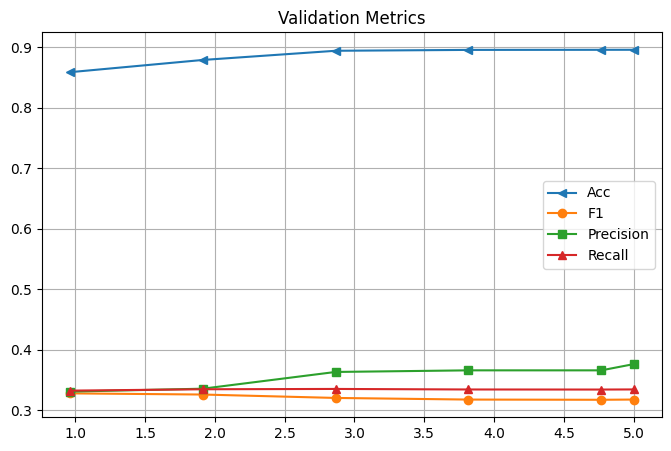

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(eval_df["epoch"], eval_df["eval_accuracy"], marker='<', label="Acc")
plt.plot(eval_df["epoch"], eval_df["eval_F1"], marker='o', label="F1")
plt.plot(eval_df["epoch"], eval_df["eval_P"], marker='s', label="Precision")
plt.plot(eval_df["epoch"], eval_df["eval_R"], marker='^', label="Recall")

plt.grid(True)
plt.legend()
plt.title("Validation Metrics")

plt.show()
